In [269]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.linalg import eigh

In [270]:
# Import Libraries
# Dataset Path
dataset_path = r"C:\Users\Nada Mamdouh\OneDrive\Documents\python\archive (5)"

# Lists to store data and labels
data = []
labels = []

# Loop through subjects
for subject in range(1, 41):

    folder_path = os.path.join(dataset_path, f"s{subject}")

    for image_name in sorted(os.listdir(folder_path)):

        image_path = os.path.join(folder_path, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        data.append(img.flatten())
        labels.append(subject)


In [271]:
# Convert lists to numpy arrays
D = np.array(data)
y = np.array(labels)

In [272]:
# Print shapes
print("Data Matrix Shape:", D.shape)
print("Label Vector Shape:", y.shape)

Data Matrix Shape: (400, 10304)
Label Vector Shape: (400,)


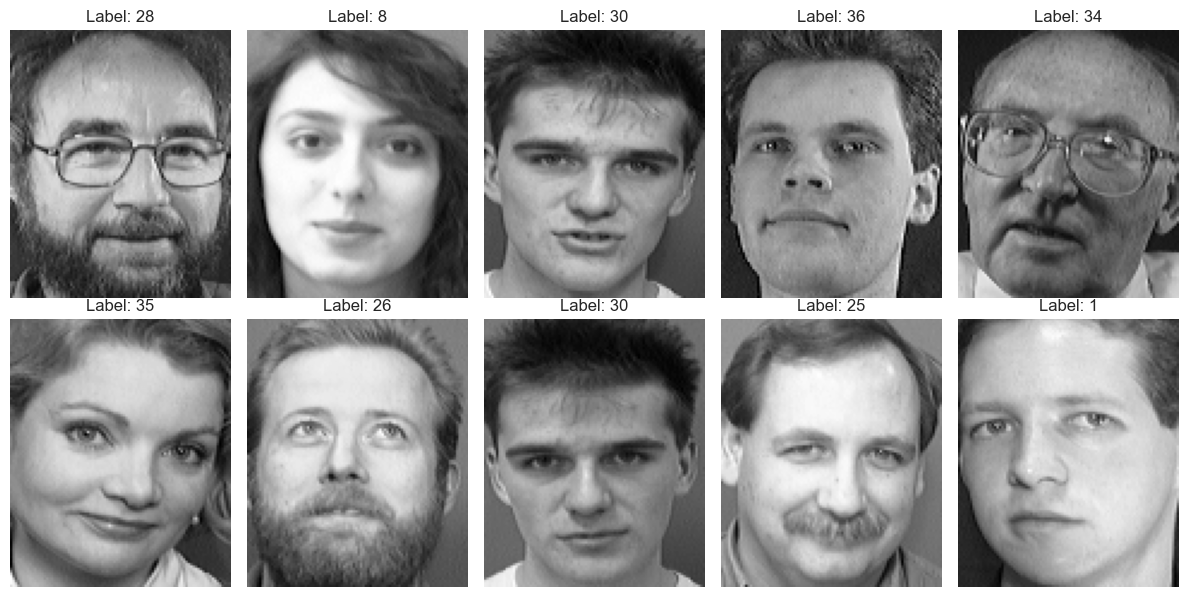

In [273]:
import matplotlib.pyplot as plt
import numpy as np

num_images = 10

plt.figure(figsize=(12, 6))

for i in range(num_images):

    idx = np.random.randint(0, len(D))  # اختيار صورة عشوائي

    img = D[idx].reshape(112, 92)  # رجّعها لشكلها الأصلي

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [274]:
# Split into Training and Testing sets

X_train = D[::2]
X_test = D[1::2]

y_train = y[::2]
y_test = y[1::2]

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (200, 10304)
X_test shape: (200, 10304)
y_train shape: (200,)
y_test shape: (200,)


In [275]:
import numpy as np
# PCA FROM SCRATCH
# =========================

mean_face = np.mean(X_train, axis=0)

X_train_c = X_train - mean_face
X_test_c = X_test - mean_face

cov = (X_train_c @ X_train_c.T) / X_train_c.shape[0]

eigvals, eigvecs_temp = eigh(cov)

eigvals = np.real(eigvals)
eigvecs_temp = np.real(eigvecs_temp)

eigvecs = X_train_c.T @ eigvecs_temp
eigvecs = eigvecs / (np.linalg.norm(eigvecs, axis=0) + 1e-10)

idx = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[idx]
eigvecs_sorted = eigvecs[:, idx]

Alpha=0.8 | Components=36 | Accuracy=0.9400
Alpha=0.85 | Components=52 | Accuracy=0.9400
Alpha=0.9 | Components=76 | Accuracy=0.9400
Alpha=0.95 | Components=115 | Accuracy=0.9300


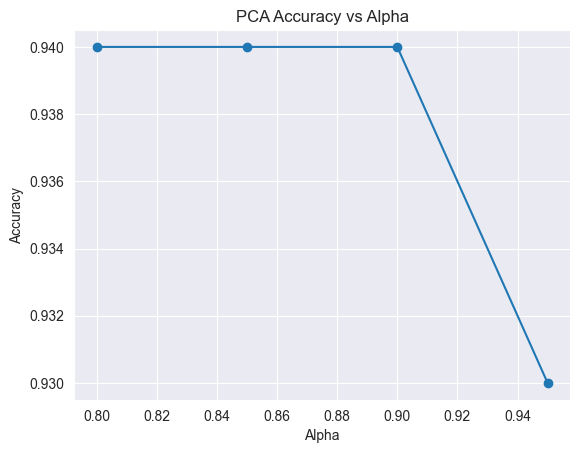

In [276]:
# PCA evaluation
# =========================

def pca(alpha):

    total = np.sum(eigvals_sorted)
    ratio = np.cumsum(eigvals_sorted) / total

    r = np.where(ratio >= alpha)[0][0] + 1

    U = eigvecs_sorted[:, :r]

    Xtr = X_train_c @ U
    Xte = X_test_c @ U

    correct = 0

    for i in range(len(Xte)):
        dist = np.linalg.norm(Xtr - Xte[i], axis=1)
        pred = y_train[np.argmin(dist)]

        if pred == y_test[i]:
            correct += 1

    return correct / len(Xte), r


alphas = [0.8, 0.85, 0.9, 0.95]
acc_list = []

for a in alphas:

    acc, r = pca(a)

    acc_list.append(acc)

    print(f"Alpha={a} | Components={r} | Accuracy={acc:.4f}")

# الرسم يكون برا الـ loop
plt.plot(alphas, acc_list, marker='o')

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("PCA Accuracy vs Alpha")
plt.grid(True)

plt.show()

In [277]:
# 🔥 FINAL FIX: PCA before LDA (IMPORTANT)
# =========================

U_pca_pre = eigvecs_sorted[:, :40]

X_train_small = X_train_c @ U_pca_pre
X_test_small = X_test_c @ U_pca_pre


In [278]:
# LDA
# =========================

overall_mean = np.mean(X_train_small, axis=0)

Sw = np.zeros((X_train_small.shape[1], X_train_small.shape[1]))
Sb = np.zeros((X_train_small.shape[1], X_train_small.shape[1]))

classes = np.unique(y_train)

for c in classes:

    Xc = X_train_small[y_train == c]
    mean_c = np.mean(Xc, axis=0)

    Sw += (Xc - mean_c).T @ (Xc - mean_c)

    n = len(Xc)
    diff = (mean_c - overall_mean).reshape(-1, 1)
    Sb += n * (diff @ diff.T)

Sw += 1e-2 * np.eye(Sw.shape[0])

eigvals_lda, eigvecs_lda = eigh(Sb, Sw)

eigvals_lda = np.real(eigvals_lda)
eigvecs_lda = np.real(eigvecs_lda)

idx = np.argsort(eigvals_lda)[::-1]

U_lda = eigvecs_lda[:, idx[:39]]

X_train_lda = X_train_small @ U_lda
X_test_lda = X_test_small @ U_lda

# =========================
# LDA classification (KNN=1 best)
# =========================

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_lda, y_train)
pred = knn.predict(X_test_lda)

lda_acc = accuracy_score(y_test, pred)

print("LDA Accuracy:", lda_acc)
best_pca = max(acc_list)

print(f"Best PCA Accuracy: {best_pca:.4f}")
print(f"LDA Accuracy: {lda_acc:.4f}")

if lda_acc > best_pca:
    print("LDA performs better than PCA")
else:
    print("PCA performs better than LDA")

LDA Accuracy: 0.955
Best PCA Accuracy: 0.9400
LDA Accuracy: 0.9550
LDA performs better than PCA



KNN Tuning Results
---------------------
K=1 | PCA=0.93 | LDA=0.955
K=3 | PCA=0.85 | LDA=0.92
K=5 | PCA=0.775 | LDA=0.915
K=7 | PCA=0.7 | LDA=0.925


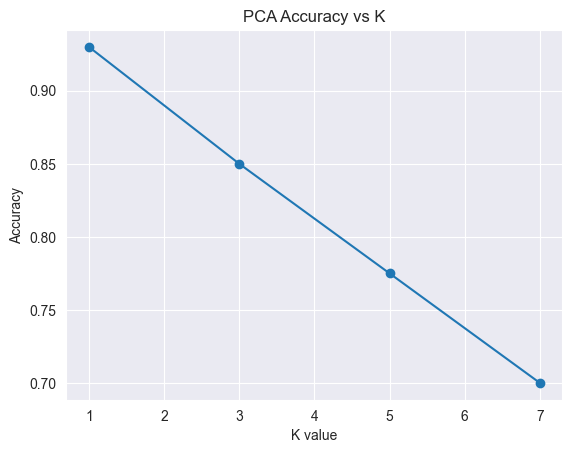

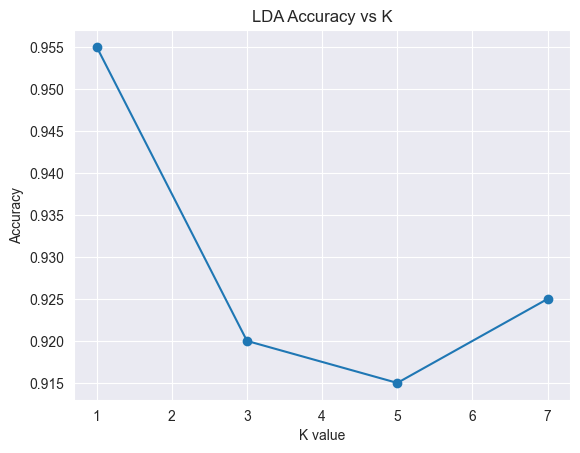


Bonus insight: LDA performs better than PCA because it maximizes class separability, not variance.


In [279]:
k_values = [1, 3, 5, 7]

_, r = pca(0.95)
U_pca = eigvecs_sorted[:, :r]

Xtr_pca = X_train_c @ U_pca
Xte_pca = X_test_c @ U_pca

pca_accs = []
lda_accs = []
print("\nKNN Tuning Results")
print("---------------------")

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(Xtr_pca, y_train)
    pca_accs.append(accuracy_score(y_test, knn.predict(Xte_pca)))

    knn.fit(X_train_lda, y_train)
    lda_accs.append(accuracy_score(y_test, knn.predict(X_test_lda)))

    print(f"K={k} | PCA={pca_accs[-1]} | LDA={lda_accs[-1]}")

plt.plot(k_values, pca_accs, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("PCA Accuracy vs K")
plt.grid(True)
plt.show()

plt.plot(k_values, lda_accs, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("LDA Accuracy vs K")
plt.grid(True)
plt.show()

# =========================
# BONUS IDEA (mention in report)
# =========================
print("\nBonus insight: LDA performs better than PCA because it maximizes class separability, not variance.")

In [280]:
# =========================
# BONUS B : 7 Train / 3 Test Split
# =========================

X_train = []
X_test = []

y_train = []
y_test = []

# لكل شخص عنده 10 صور
for i in range(40):

    start = i * 10

    # أول 7 صور للتدريب
    X_train.extend(D[start:start+7])

    # آخر 3 صور للاختبار
    X_test.extend(D[start+7:start+10])

    # labels
    y_train.extend(y[start:start+7])
    y_test.extend(y[start+7:start+10])

# تحويل لـ numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

# =========================
# Print Shapes
# =========================

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# =========================
# PCA AGAIN
# =========================

mean_face = np.mean(X_train, axis=0)

X_train_c = X_train - mean_face
X_test_c = X_test - mean_face

cov = (X_train_c @ X_train_c.T) / X_train_c.shape[0]

eigvals, eigvecs_temp = eigh(cov)

eigvals = np.real(eigvals)
eigvecs_temp = np.real(eigvecs_temp)

eigvecs = X_train_c.T @ eigvecs_temp
eigvecs = eigvecs / (np.linalg.norm(eigvecs, axis=0) + 1e-10)

idx = np.argsort(eigvals)[::-1]

eigvals_sorted = eigvals[idx]
eigvecs_sorted = eigvecs[:, idx]

# =========================
# PCA FUNCTION
# =========================

def pca(alpha):

    total = np.sum(eigvals_sorted)

    ratio = np.cumsum(eigvals_sorted) / total

    r = np.where(ratio >= alpha)[0][0] + 1

    U = eigvecs_sorted[:, :r]

    Xtr = X_train_c @ U
    Xte = X_test_c @ U

    knn = KNeighborsClassifier(n_neighbors=1)

    knn.fit(Xtr, y_train)

    pred = knn.predict(Xte)

    acc = accuracy_score(y_test, pred)

    return acc, r

# =========================
# PCA RESULTS
# =========================

alphas = [0.8, 0.85, 0.9, 0.95]

print("\nPCA Results (7/3 Split)")
print("------------------------")

for a in alphas:

    acc, r = pca(a)

    print(f"Alpha={a} | Components={r} | Accuracy={acc:.4f}")

# =========================
# LDA
# =========================

U_pca_pre = eigvecs_sorted[:, :160]

X_train_small = X_train_c @ U_pca_pre
X_test_small = X_test_c @ U_pca_pre

overall_mean = np.mean(X_train_small, axis=0)

Sw = np.zeros((X_train_small.shape[1], X_train_small.shape[1]))
Sb = np.zeros((X_train_small.shape[1], X_train_small.shape[1]))

classes = np.unique(y_train)

for c in classes:

    Xc = X_train_small[y_train == c]

    mean_c = np.mean(Xc, axis=0)

    Sw += (Xc - mean_c).T @ (Xc - mean_c)

    n = len(Xc)

    diff = (mean_c - overall_mean).reshape(-1,1)

    Sb += n * (diff @ diff.T)

Sw += 1e-2 * np.eye(Sw.shape[0])

eigvals_lda, eigvecs_lda = eigh(Sb, Sw)

eigvals_lda = np.real(eigvals_lda)
eigvecs_lda = np.real(eigvecs_lda)

idx = np.argsort(eigvals_lda)[::-1]

U_lda = eigvecs_lda[:, idx[:39]]

X_train_lda = X_train_small @ U_lda
X_test_lda = X_test_small @ U_lda

# =========================
# LDA Classification
# =========================

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train_lda, y_train)

pred = knn.predict(X_test_lda)

lda_acc = accuracy_score(y_test, pred)

print("\nLDA Accuracy (7/3 Split):", lda_acc)

X_train shape: (280, 10304)
X_test shape: (120, 10304)
y_train shape: (280,)
y_test shape: (120,)

PCA Results (7/3 Split)
------------------------
Alpha=0.8 | Components=38 | Accuracy=0.9667
Alpha=0.85 | Components=57 | Accuracy=0.9583
Alpha=0.9 | Components=89 | Accuracy=0.9500
Alpha=0.95 | Components=145 | Accuracy=0.9417

LDA Accuracy (7/3 Split): 0.925


In [281]:
data = []
labels = []

In [282]:
dataset_path = r"C:\Users\Nada Mamdouh\OneDrive\Documents\python\archive (5)"

for subject in range(1, 41):

    folder_path = os.path.join(dataset_path, f"s{subject}")

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        data.append(img.flatten())

        labels.append(1)   # face = 1

In [283]:
non_face_path =r"C:\Users\Nada Mamdouh\OneDrive\Documents\python\non_face"

for image_name in sorted(os.listdir(non_face_path)):

    image_path = os.path.join(non_face_path, image_name)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
      continue

    img = cv2.resize(img, (92, 112))

    data.append(img.flatten())

    labels.append(0)   # non-face = 0

In [284]:
D = np.array(data, dtype=np.float64)
y = np.array(labels)

print(D.shape)
print(y.shape)

(601, 10304)
(601,)


In [285]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    D, y,
    test_size=0.3,
    random_state=42,
    stratify=y#مهم جدًا علشان يوزّع faces و non-faces بعدل
)

In [286]:
mean_face = np.mean(X_train, axis=0)

X_train_c = X_train - mean_face
X_test_c = X_test - mean_face

cov = (X_train_c @ X_train_c.T) / X_train_c.shape[0]

eigvals, eigvecs_temp = eigh(cov)

eigvecs = X_train_c.T @ eigvecs_temp
eigvecs = eigvecs / (np.linalg.norm(eigvecs, axis=0) + 1e-10)

idx = np.argsort(eigvals)[::-1]
eigvecs_sorted = eigvecs[:, idx]

In [287]:
U_pca = eigvecs_sorted[:, :50]

Xtr = X_train_c @ U_pca
Xte = X_test_c @ U_pca

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(Xtr, y_train)

pred = knn.predict(Xte)

print("PCA Accuracy:", accuracy_score(y_test, pred))

PCA Accuracy: 0.9723756906077348


In [288]:
Sw = np.zeros((Xtr.shape[1], Xtr.shape[1]))
Sb = np.zeros((Xtr.shape[1], Xtr.shape[1]))

overall_mean = np.mean(Xtr, axis=0)

for c in np.unique(y_train):

    Xc = Xtr[y_train == c]
    mean_c = np.mean(Xc, axis=0)

    Sw += (Xc - mean_c).T @ (Xc - mean_c)

    diff = (mean_c - overall_mean).reshape(-1,1)

    Sb += len(Xc) * diff @ diff.T
Sw += 1e-2 * np.eye(Sw.shape[0])

In [289]:
eigvals_lda, eigvecs_lda = eigh(Sb, Sw)

idx = np.argsort(eigvals_lda)[::-1]

U_lda = eigvecs_lda[:, idx[:1]]

Xtr_lda = Xtr @ U_lda
Xte_lda = Xte @ U_lda

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(Xtr_lda, y_train)

pred_lda = knn.predict(Xte_lda)

print("LDA Accuracy:", accuracy_score(y_test, pred_lda))

LDA Accuracy: 0.9668508287292817


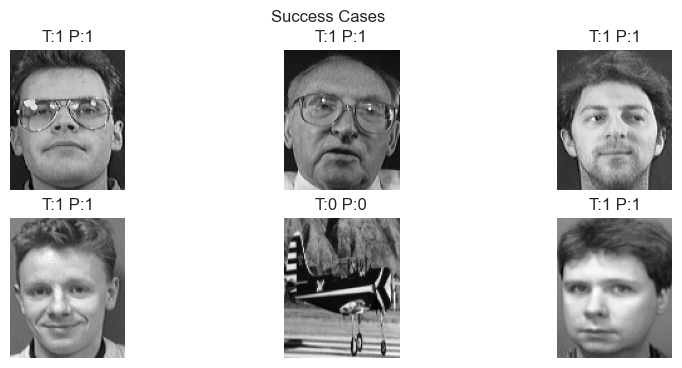

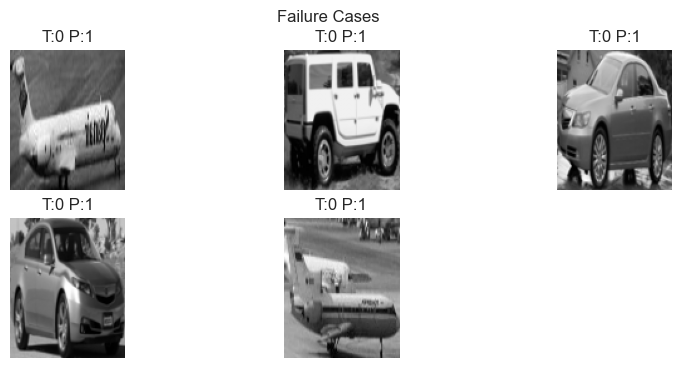

In [290]:
import matplotlib.pyplot as plt

def show_samples(X, y_true, y_pred, title):
    plt.figure(figsize=(10,4))

    n = min(6, len(X))   # 👈 أهم سطر

    for i in range(n):
        plt.subplot(2,3,i+1)
        plt.imshow(X[i].reshape(112,92), cmap='gray')
        plt.title(f"T:{y_true[i]} P:{y_pred[i]}")
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

# Success cases
correct_idx = np.where(pred == y_test)[0]
show_samples(X_test[correct_idx], y_test[correct_idx], pred[correct_idx], "Success Cases")

# Failure cases
wrong_idx = np.where(pred != y_test)[0]
show_samples(X_test[wrong_idx], y_test[wrong_idx], pred[wrong_idx], "Failure Cases")

In [291]:
# =========================
# BONUS A: Accuracy vs Number of Non-Faces
# =========================

non_face_counts = [20, 50, 100, 200]
accuracies = []

face_data = D[y == 1]
face_labels = y[y == 1]

non_face_data = D[y == 0]

for n in non_face_counts:

    idx = np.random.choice(len(non_face_data), n, replace=False)
    nf_data = non_face_data[idx]
    nf_labels = np.zeros(n)

    X = np.vstack((face_data, nf_data))
    Y = np.hstack((face_labels, nf_labels))

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y,
        test_size=0.3,
        random_state=42,
        stratify=Y
    )

    # PCA
    mean_face = np.mean(X_train, axis=0)
    Xtr_c = X_train - mean_face
    Xte_c = X_test - mean_face

    cov = (Xtr_c @ Xtr_c.T) / Xtr_c.shape[0]
    eigvals, eigvecs_temp = eigh(cov)

    eigvecs = Xtr_c.T @ eigvecs_temp
    eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)

    idx = np.argsort(eigvals)[::-1]
    U_pca = eigvecs[:, idx[:50]]

    Xtr_pca = Xtr_c @ U_pca
    Xte_pca = Xte_c @ U_pca

    # KNN
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(Xtr_pca, y_train)

    pred = knn.predict(Xte_pca)
    acc = accuracy_score(y_test, pred)

    accuracies.append(acc)

    print(f"Non-faces = {n} | Accuracy = {acc:.4f}")

Non-faces = 20 | Accuracy = 0.9603
Non-faces = 50 | Accuracy = 0.9481
Non-faces = 100 | Accuracy = 0.9467
Non-faces = 200 | Accuracy = 0.9556


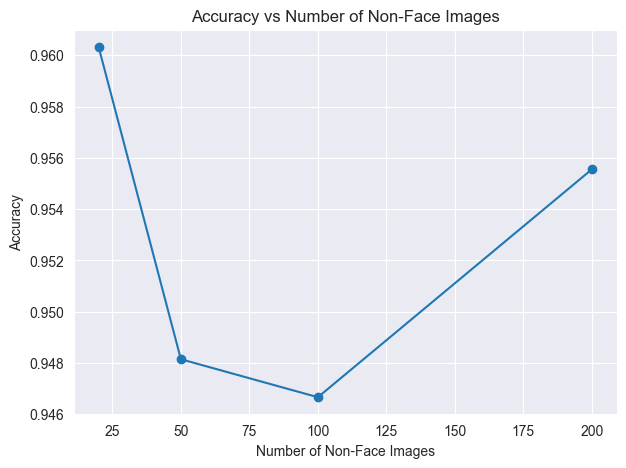

In [292]:
plt.figure(figsize=(7,5))
plt.plot(non_face_counts, accuracies, marker='o')
plt.xlabel("Number of Non-Face Images")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Non-Face Images")
plt.grid(True)
plt.show()